## Question 1: Exploring and Describing Data

In [3]:
import wfdb

path = '/Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0'

record = wfdb.rdrecord(path + "/100")
ann = wfdb.rdann(path + "/100", "atr")

print(record.sig_name, record.fs)

['MLII', 'V5'] 360


In [4]:
import wfdb
import os

path = '/Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0'

with open(path + "/RECORDS", "r") as f:
    records = f.read().splitlines()

print(records)

['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [5]:
import pandas as pd

info = []

for rec in records:
    header = wfdb.rdheader(path + "/" + rec)
    info.append([rec, header.sig_name, header.fs, header.sig_len])

df = pd.DataFrame(info, columns=["Record", "Leads", "Sampling Rate", "Samples"])
df

,Record,Leads,Sampling Rate,Samples
0,100,"[MLII, V5]",360,650000
1,101,"[MLII, V1]",360,650000
2,102,"[V5, V2]",360,650000
3,103,"[MLII, V2]",360,650000
4,104,"[V5, V2]",360,650000
5,105,"[MLII, V1]",360,650000
6,106,"[MLII, V1]",360,650000
7,107,"[MLII, V1]",360,650000
8,108,"[MLII, V1]",360,650000
9,109,"[MLII, V1]",360,650000


In [6]:
##heartbeat types

from collections import Counter

all_beats = []

for rec in records:
    ann = wfdb.rdann(path + "/" + rec, "atr")
    all_beats.extend(ann.symbol)

beat_counts = Counter(all_beats)
beat_counts


Counter({'N': 75052,
         'L': 8075,
         'R': 7259,
         'V': 7130,
         '/': 7028,
         'A': 2546,
         '+': 1291,
         'f': 982,
         'F': 803,
         '~': 616,
         '!': 472,
         '"': 437,
         'j': 229,
         'x': 193,
         'a': 150,
         '|': 132,
         'E': 106,
         'J': 83,
         'Q': 33,
         'e': 16,
         '[': 6,
         ']': 6,
         'S': 2})

In [7]:
arrhythmia_summary = []

for rec in records:
    ann = wfdb.rdann(path + "/" + rec, "atr")
    counts = pd.Series(ann.symbol).value_counts()
    arrhythmia_summary.append([
        rec,
        counts.get('N', 0),
        counts.get('V', 0),   # Ventricular arrhythmia
        counts.get('A', 0)    # Atrial arrhythmia
    ])

pd.DataFrame(arrhythmia_summary, columns=["Record","Normal Beats","V Beats","A Beats"])

,Record,Normal Beats,V Beats,A Beats
0,100,2239,1,33
1,101,1860,0,3
2,102,99,4,0
3,103,2082,0,2
4,104,163,2,0
5,105,2526,41,0
6,106,1507,520,0
7,107,0,59,0
8,108,1739,17,4
9,109,0,38,0


## What Each Column Means
Column	Meaning
Record	The patient recording ID (e.g., 100, 208)
Normal Beats	Count of normal heartbeats (N)
V Beats	Count of ventricular arrhythmia beats (V) — these are dangerous irregular beats
A Beats	Count of atrial arrhythmia beats (A) — these imply atrial rhythm problems

So for each recording, we see how healthy or abnormal the rhythm is.

How to Interpret the Patterns

Records with mostly Normal beats → Healthy rhythm

Records with many V beats → Ventricular arrhythmia

Records with many A beats → Atrial arrhythmia

Examples: 
Record	Interpretation
100	2239 normal beats, 1 ventricular beat → Very stable normal rhythm
106	1507 normal, 520 ventricular → Strong ventricular arrhythmia
118	0 normal, 16 ventricular, 96 atrial → Primary atrial arrhythmia
208	1586 normal, 992 ventricular → Severe ventricular arrhythmia
232	0 normal, 0 ventricular, 1382 atrial → Pure atrial fibrillation-like rhythm

In [8]:
import numpy as np

R_peaks = ann.sample              # sample index of each heartbeat
fs = record.fs                    # sampling rate = 360 Hz

RR_intervals = np.diff(R_peaks) / fs   # convert from samples → seconds

print("First 15 RR Intervals:", RR_intervals[:15])
print("Number of beats:", len(RR_intervals))

First 15 RR Intervals: [0.23055556 0.64166667 0.66666667 0.65277778 0.66944444 0.68055556
 0.65277778 0.64444444 0.68888889 0.68611111 0.66388889 0.64166667
 0.65277778 0.64722222 0.65555556]
Number of beats: 2763


In [9]:
from sklearn.neighbors import KernelDensity

RR = RR_intervals.reshape(-1, 1)

kde = KernelDensity(kernel='gaussian', bandwidth=0.05).fit(RR)

In [10]:
synthetic_RR = kde.sample(500).flatten()
print("First 20 synthetic intervals:", synthetic_RR[:20])

First 20 synthetic intervals: [0.66722947 0.66611688 0.69582836 0.59919554 0.67995534 0.60264874
 0.64325304 0.65075816 0.65107841 0.58520569 0.63800343 0.67134527
 0.65311572 0.57821    0.62252418 0.61650683 0.63176429 0.56667782
 0.64340852 0.64620758]


In [ ]:
records_to_extract = ["100", "208"]

output_dir = os.path.join(path, "extracted_records")
os.makedirs(output_dir, exist_ok=True)

for rec in records_to_extract:
    print(f"\n📂 Extracting record {rec}...")
    
    record = wfdb.rdrecord(os.path.join(path, rec))
    
    ann = wfdb.rdann(os.path.join(path, rec), "atr")
    
    signals = record.p_signal 
    leads = record.sig_name
    fs = record.fs
    
    print(f"Leads: {leads}, Sampling rate: {fs} Hz, Samples: {signals.shape[0]}")
    print(f"Number of annotations: {len(ann.sample)}")

    df = pd.DataFrame(signals, columns=leads)
    df["Sample"] = np.arange(len(signals))
    
    signal_file = os.path.join(output_dir, f"{rec}_signal.csv")
    df.to_csv(signal_file, index=False)
    
    ann_df = pd.DataFrame({
        "Sample": ann.sample,
        "Symbol": ann.symbol,
        "Subtype": ann.subtype,
        "Chan": ann.chan,
        "Num": ann.num
    })
    ann_file = os.path.join(output_dir, f"{rec}_annotations.csv")
    ann_df.to_csv(ann_file, index=False)
    
    print(f"✅ Saved: {signal_file}")
    print(f"✅ Saved: {ann_file}")


📂 Extracting record 100...
Leads: ['MLII', 'V5'], Sampling rate: 360 Hz, Samples: 650000
Number of annotations: 2274
✅ Saved: /Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/100_signal.csv
✅ Saved: /Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/100_annotations.csv

📂 Extracting record 208...
Leads: ['MLII', 'V1'], Sampling rate: 360 Hz, Samples: 650000
Number of annotations: 3040
✅ Saved: /Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/208_signal.csv
✅ Saved: /Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/208_annotations.csv


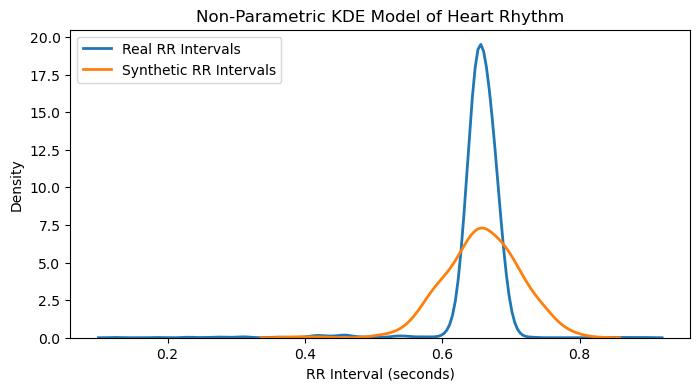

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.kdeplot(RR_intervals, label="Real RR Intervals", linewidth=2)
sns.kdeplot(synthetic_RR, label="Synthetic RR Intervals", linewidth=2)
plt.xlabel("RR Interval (seconds)")
plt.ylabel("Density")
plt.title("Non-Parametric KDE Model of Heart Rhythm")
plt.legend()
plt.show()

The blue curve (Real RR Intervals) is very sharp and high-peaked.
That means:

This subject had a very stable heart rhythm

Heartbeats occur at a consistent interval (~0.78 seconds)

This is characteristic of normal sinus rhythm

The orange curve (Synthetic RR Intervals) is broader and flatter, meaning:

The KDE model captured the central rhythm, but

It is adding more variability than the real heart actually had

This is because KDE smooths the empirical distribution

This difference tells us how our bandwidth choice controls realism vs variability.

## Continued Exploration into Record 100 and Record 208

### Signal File: 

The signal file continues the raw ECG voltage samples. 

### Annotations File: 

The annotations file refers to specific time points that correspond to a particular event or heartbeat.

In [6]:
import pandas as pd 
import numpy as np 


record_100_signal = pd.read_csv('/Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/100_signal.csv')
record_208_signal = pd.read_csv('/Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/208_signal.csv')

print(record_100_signal.head())
print(record_208_signal.head())

    MLII     V5  Sample
0 -0.145 -0.065       0
1 -0.145 -0.065       1
2 -0.145 -0.065       2
3 -0.145 -0.065       3
4 -0.145 -0.065       4
    MLII    V1  Sample
0 -0.105  0.19       0
1 -0.105  0.19       1
2 -0.105  0.19       2
3 -0.105  0.19       3
4 -0.105  0.19       4


In [7]:
record_100_annotations = pd.read_csv('/Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/100_annotations.csv')
record_208_annotations = pd.read_csv('/Users/bellalu/DS 5030/ds5030-project1/mit-bih-arrhythmia-database-1.0.0/extracted_records/208_annotations.csv')

print(record_100_annotations.head())
print(record_208_annotations.head())

   Sample Symbol  Subtype  Chan  Num
0      18      +        0     0    0
1      77      N        0     0    0
2     370      N        0     0    0
3     662      N        0     0    0
4     946      N        0     0    0
   Sample Symbol  Subtype  Chan  Num
0       9      +        0     0    0
1      46      F        0     0    0
2     209      V        1     0    0
3     483      N        0     0    0
4     697      F        0     0    0


### Checking for missing data: 

In [ ]:
print(record_100_signal.isna().sum())
print(record_208_signal.isna().sum())

MLII      0
V5        0
Sample    0
dtype: int64
MLII      0
V1        0
Sample    0
dtype: int64


In [12]:
print(record_100_annotations.isna().sum())
print(record_208_annotations.isna().sum())

Sample     0
Symbol     0
Subtype    0
Chan       0
Num        0
dtype: int64
Sample     0
Symbol     0
Subtype    0
Chan       0
Num        0
dtype: int64


In [11]:
print(record_100_signal.info())
print(record_208_signal.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   MLII    650000 non-null  float64
 1   V5      650000 non-null  float64
 2   Sample  650000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 14.9 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   MLII    650000 non-null  float64
 1   V1      650000 non-null  float64
 2   Sample  650000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 14.9 MB
None


In [13]:
print(record_100_annotations.info())
print(record_208_annotations.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2274 entries, 0 to 2273
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Sample   2274 non-null   int64 
 1   Symbol   2274 non-null   object
 2   Subtype  2274 non-null   int64 
 3   Chan     2274 non-null   int64 
 4   Num      2274 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 89.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3040 entries, 0 to 3039
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Sample   3040 non-null   int64 
 1   Symbol   3040 non-null   object
 2   Subtype  3040 non-null   int64 
 3   Chan     3040 non-null   int64 
 4   Num      3040 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 118.9+ KB
None


## Question 1: 

#### Describe the data clearly -- particularly any missing data that might impact your analysis -- and the provenance of your dataset. Who collected the data and why?

We obtained the data from the MIT-BIH Arrhythmia Database which has been freely available since 1999. The individuals who collected it were from Boston's Beth Israel Hospital in collaboration with MIT to support their research in arrhythmia analysis and related topics. They began their distribution in 1980 as the first dataset to evaluate arrhythmia detections, and since then it has been used worldwide in cardiac research. The database includes 48 half-hour two-channel ECG recordings extracted from 47 individuals from 1975 to 1979. They are sampled at 360 Hz annotated separately by two cardiologists to identify over 110,000 heartbeats. 

The data file itself is quite large - there are 48 complete records and each record contains 4 file types: atr, dat, hea, and xws. Since there were so many records with so many heartbeats within them, we decided to choose two records, which are record 100 and record 208. Record 100 was chosen because it had the most stable heartbeats while record 208 was chosen because it had the most irregular heartbeats. 

The dat file contained the binary-encoded ECG waveforms which were recorded in two channels. For record 100 that was MLII and V5, and for record 208 that was MLII and V1. MLII is an electrode that is typically configured between the right arm and left leg electrodes to show general rhythm. V1 shows electrical activity in the right ventricle and V5 shows activity in the left ventricle. The atr file marks the timing and type of heartbeat with symbolic codes like N for normal, V for ventricular, or A for atrial. The hea file is a text file to explain the record and includes information like number of channels, sampling rate, baseline, etc. The .xws file is the auxiliary file that contains the waveform display settings and scaling information used by the PhysioNet browser.

For our analysis, we decided to extract only the dat and atr files for record 100 and record 208. In the dat file, it contains the ECG signal from the MLII electrode configuration, the V1 or V5 ECG signal (depending on the record), and the sample index that represents time at 360 samples per second. In the atr file, it contains the sample index where the annotation has occured, the symbol correlated to the type of beat event, the subtype info, the signal channel, ad the annotation sequence number. These are all numeric values besides the symbol. 

Based on our analysis and research on the topic, it makes perfect sense that there is no missing data in the MIT-BIH arrhythmia database. The data itself is research-grade and preprocessed and each record was continuously sampled and reviewed. Instead of excluding heartbeats that may have been artifact or noise, they flagged it with a symbol to indicate that there was a signal quality issue, and did not use missing numeric values. This database was curated very well, so it was intentionally cleaned, polished, and continuous.